## Models Training

In [1]:
# import library
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, PowerTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
## Load feature engineered dataset into a dataframe
df = pd.read_csv("../data/processed/feature_engineered_flipcart_laptop_data.csv")

## Top five observations
df.head()

,Discount price,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,54990.0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,67990.0,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,35660.0,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,26990.0,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,27989.0,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Discount price        923 non-null    float64
 1   Stars                 923 non-null    float64
 2   Rating                923 non-null    float64
 3   Reviews               923 non-null    float64
 4   discount_pct(%)       923 non-null    float64
 5   brand                 923 non-null    str    
 6   ram_gb                923 non-null    float64
 7   storage_gb            923 non-null    float64
 8   storage_type          923 non-null    str    
 9   processor_tier        923 non-null    str    
 10  is_gaming             923 non-null    int64  
 11  processor_brand       923 non-null    str    
 12  processor_generation  923 non-null    int64  
 13  premium_brand         923 non-null    int64  
dtypes: float64(7), int64(3), str(4)
memory usage: 101.1 KB


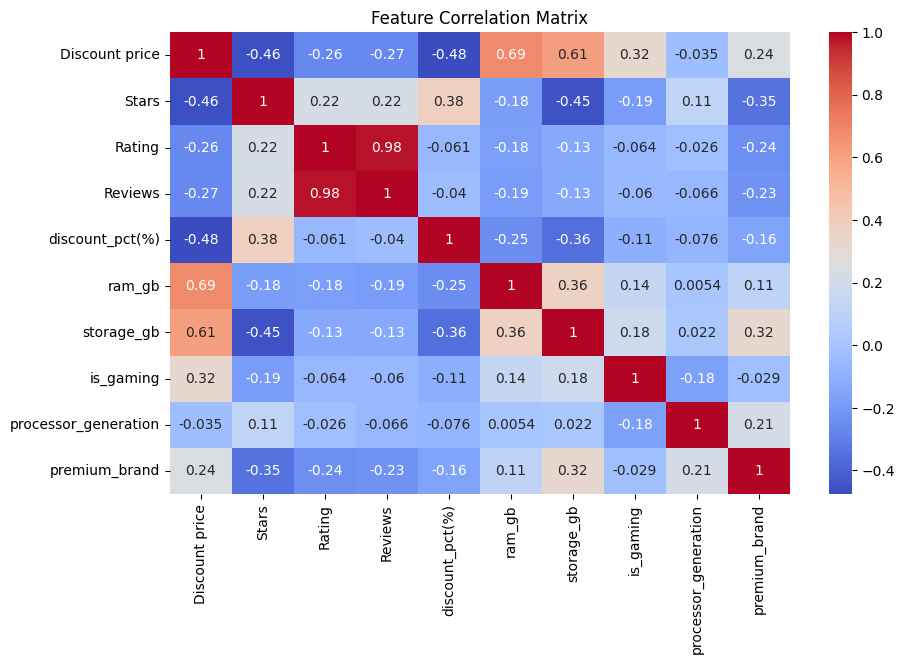

In [4]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

### Create Features and Target Variable

In [5]:
# Features
X = df.drop(columns=['Discount price'])
# Target
y = df["Discount price"]

X.head()

,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
0,3.9,7.0,1.0,38.89,MSI,16.0,512.0,SSD,Mid,0,Intel,12,1
1,0.0,0.0,0.0,19.05,MSI,8.0,1024.0,SSD,High,0,Intel,12,1
2,4.2,1805.0,143.0,27.58,DELL,8.0,512.0,SSD,Entry,0,Intel,12,0
3,4.2,6977.0,596.0,38.66,Acer,8.0,512.0,SSD,Entry,0,Intel,11,0
4,4.2,1263.0,113.0,52.88,Lenovo,8.0,512.0,SSD,Entry,0,AMD,0,0


In [6]:
X.shape

(923, 13)

In [7]:
y.head()

0    54990.0
1    67990.0
2    35660.0
3    26990.0
4    27989.0
Name: Discount price, dtype: float64

### Splitting into training and testing set

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train", X_train.shape)
print("Shape of X_test", X_test.shape)
print("Shape of y_train", y_train.shape)
print("Shape of y_test", y_test.shape)

Shape of X_train (738, 13)
Shape of X_test (185, 13)
Shape of y_train (738,)
Shape of y_test (185,)


In [9]:
X_train.head()

,Stars,Rating,Reviews,discount_pct(%),brand,ram_gb,storage_gb,storage_type,processor_tier,is_gaming,processor_brand,processor_generation,premium_brand
97,3.7,602.0,76.0,52.51,CHUWI,8.0,256.0,SSD,Entry,0,Intel,11,0
227,3.8,69.0,8.0,36.39,Acer,8.0,512.0,SSD,Entry,0,Intel,0,0
692,4.5,13.0,3.0,30.27,ASUS,16.0,512.0,SSD,Other,1,AMD,0,0
587,5.0,3.0,0.0,31.26,Thomson,8.0,256.0,SSD,Entry,0,Intel,12,0
883,3.8,611.0,53.0,30.08,HP,8.0,256.0,SSD,Entry,0,Intel,0,0


In [10]:
## Initialize the PowerTransformer
yeo_trf = PowerTransformer(method='yeo-johnson')

## Instantiate of log transformer
log_trf = FunctionTransformer(np.log1p)

## Pipeline for sequential execution
numeric_pipeline = Pipeline([
    ("log_transform", log_trf),
    ("scaler", StandardScaler())
])

yeo_pipeline = Pipeline([
    ("yeo_transform", yeo_trf),
    ("scaler", StandardScaler())
])

In [11]:
## Create Column Transformer
transformer = ColumnTransformer(
    transformers=[
        ("numeric_pipeline", numeric_pipeline, ["Rating", "Reviews", "ram_gb", "storage_gb", "discount_pct(%)"]),
        ("yeo_pipeline", yeo_pipeline, ["Stars"]),

        # 1. TARGET ENCODING FOR BRAND (Keeps it as 1 column)
        ("target_enc", TargetEncoder(smooth="auto", cv=5, target_type='continuous'), ["brand"]),

        ("OneHotEncoding", OneHotEncoder(
            drop='first',
            min_frequency=6,          # Categories appearing < 6 times become 'Other'
            handle_unknown='infrequent_if_exist', 
            sparse_output=False
            ), ["storage_type", "processor_brand"]
        ),

        ("OrdinalEncoding",OrdinalEncoder(categories=[["Entry", "Mid", "High", "Ultra", "Other"]]),["processor_tier"])
    ],
    
    remainder='passthrough'
)

In [12]:
## Fit and Transform the Training Set
X_train_trf = transformer.fit_transform(X_train, y_train)
X_train_trf

array([[ 0.73265806,  0.81248057, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [-0.0133741 , -0.15594907, -0.742441  , ...,  0.        ,
         0.        ,  0.        ],
       [-0.57094826, -0.52180012,  0.9923504 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.74507256,  0.98553372, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [ 0.72097263,  0.69235381, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [ 1.09538068,  1.10112679,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ]], shape=(738, 14))

In [13]:
X_train_trf.shape

(738, 14)

In [14]:
## Transform only Testing set
X_test_trf = transformer.transform(X_test)
X_test_trf

array([[-1.48522409, -1.14722663,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ],
       [ 0.97077548,  0.97747726, -0.742441  , ...,  0.        ,
        11.        ,  0.        ],
       [-0.76482173, -0.83451337,  0.9923504 , ...,  0.        ,
        12.        ,  1.        ],
       ...,
       [ 1.30019916,  1.29019051, -0.742441  , ...,  0.        ,
        12.        ,  0.        ],
       [-1.48522409, -1.14722663,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ],
       [-1.00495585, -0.83451337,  0.9923504 , ...,  0.        ,
        12.        ,  0.        ]], shape=(185, 14))

### Train different models

- #### Linear Regression 

In [15]:
from sklearn.linear_model import LinearRegression

## Create instantiate
lr = LinearRegression()

## Fit the dataset into model
lr.fit(X_train_trf, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
## Prediction On Training Set
lr_train_pred = lr.predict(X_train_trf)

## Prediction on Testing Set
lr_pred = lr.predict(X_test_trf)

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Mean Square Error
lr_mse = mean_squared_error(y_true=y_train, y_pred=lr_train_pred)
## Mean Absolute Error
lr_mae = mean_absolute_error(y_true=y_train, y_pred=lr_train_pred)
## R2 score
lr_r2_score = r2_score(y_true=y_train, y_pred=lr_train_pred)

print("MSE: ", lr_mse)
print("MAE: ", lr_mae)
print("R2-Score: ", lr_r2_score)

MSE:  204605419.30848822
MAE:  9624.701506233609
R2-Score:  0.7345080621146524


In [19]:
## Mean Square Error
lr_test_mse = mean_squared_error(y_true=y_test, y_pred=lr_pred)
## Mean Absolute Error
lr_test_mae = mean_absolute_error(y_true=y_test, y_pred=lr_pred)
## R2 score
lr_test_r2_score = r2_score(y_true=y_test, y_pred=lr_pred)

print("MSE: ", lr_test_mse)
print("MAE: ", lr_test_mae)
print("R2-Score: ", lr_test_r2_score)

MSE:  736971269.4283952
MAE:  12419.208414496881
R2-Score:  0.5852336882910334


- #### Lasso Regression

In [20]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

lasso_pipeline = Pipeline([
    ('preprocessor', transformer),
    ('model', Lasso(max_iter=10000, random_state=42)) # Increased iterations for convergence
])

# Define the alpha grid (smaller alpha = less regularization, larger = more)
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train, y_train)

# Print best parameters and scores
print(f"Best Alpha: {grid_search.best_params_}")
print(f"Train R2 Score: {grid_search.cv_results_['mean_train_score'][grid_search.best_index_]:.4f}")
print(f"Validation R2 Score: {grid_search.best_score_:.4f}")

Best Alpha: {'model__alpha': 1.0}
Train R2 Score: 0.7377
Validation R2 Score: 0.7210


In [21]:
# Check which features Lasso selected (kept non-zero)
best_model = grid_search.best_estimator_.named_steps['model']
print(f"Total features: {len(best_model.coef_)}")
print(f"Features kept by Lasso: {sum(best_model.coef_ != 0)}")

Total features: 14
Features kept by Lasso: 14


In [22]:
best_model.coef_

array([-2.10001993e+02, -2.90421943e+03,  7.04385085e+03,  4.55538586e+03,
       -8.01355268e+03, -1.65550918e+03,  3.73123672e-01, -3.69463191e+04,
       -1.59281321e+04, -1.71794049e+03,  8.19900217e+03,  2.01684458e+04,
        3.95866689e+02, -5.78302135e+03])

In [23]:
# import pandas as pd
# import numpy as np

# ## Extract the fitted preprocessor
# fitted_preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

# ## Reconstruct names safely by block sequence
# numeric_cols = ["Rating", "Reviews", "ram_gb", "storage_gb", "discount_pct(%)"]
# yeo_cols = ["Stars"]
# brand_cols = ["brand"]

# # Extract dynamic column names from the One-Hot Encoder
# ohe_step = fitted_preprocessor.named_transformers_['OneHotEncoding']
# ohe_cols = list(ohe_step.get_feature_names_out(["storage_type", "processor_brand"]))

# ordinal_cols = ["processor_tier"]

# # Extract remainder columns manually from ColumnTransformer configuration
# # These are the columns not mention in any other transformer block
# all_transformed = set(numeric_cols + yeo_cols + brand_cols + ["storage_type", "processor_brand"] + ordinal_cols)
# remainder_cols = [col for col in X_train.columns if col not in all_transformed]

# # Combine everything in the exact order of ColumnTransformer definition
# feature_names = numeric_cols + yeo_cols + brand_cols + ohe_cols + ordinal_cols + remainder_cols

# ## Pull coefficients from the model
# best_lasso_model = grid_search.best_estimator_.named_steps['model']
# coefficients = best_lasso_model.coef_

# ## Check array length to ensure it perfectly matches up
# if len(feature_names) == len(coefficients):
#     feature_importance_df = pd.DataFrame({
#         'Feature': feature_names,
#         'Coefficient': coefficients,
#         'Absolute_Coefficient': np.abs(coefficients)
#     }).sort_values(by='Absolute_Coefficient', ascending=False)
    
#     print("\n--- Features Kept vs. Dropped by Lasso Regularization ---\n")
#     print(feature_importance_df)
# else:
#     print(f"Error: Array lengths mismatch. Expected {len(coefficients)} names, but manually constructed {len(feature_names)}.")


In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

## Retrieve the optimal model pipeline from grid search
best_lasso_pipeline = grid_search.best_estimator_

## Generate predictions for both datasets
y_train_pred = best_lasso_pipeline.predict(X_train)
y_test_pred = best_lasso_pipeline.predict(X_test)

## Calculate Performance Metrics
metrics_summary = {
    "Metric": ["R² Score", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Train Set": [
        r2_score(y_train, y_train_pred),
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    ],
    "Test Set": [
        r2_score(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ]
}

## Format and display the results cleanly
import pandas as pd
metrics_df = pd.DataFrame(metrics_summary)
print("\n--- Final Lasso Model Evaluation Summary ---\n")
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



--- Final Lasso Model Evaluation Summary ---

                        Metric  Train Set   Test Set
                      R² Score     0.7357     0.5859
     Mean Absolute Error (MAE)  9608.2790 12397.0104
Root Mean Squared Error (RMSE) 14272.2774 27123.8951


- #### Decision Tree

In [25]:
from sklearn.tree import DecisionTreeRegressor

## Create instantiate
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [26]:
## Train the model
dt_reg.fit(X_train_trf, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [27]:
## Prediction on the training dataset
dt_train_pred = dt_reg.predict(X_train_trf)

## Prediction on the testing dataset
dt_test_pred = dt_reg.predict(X_test_trf)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Mean Square Error
dt_mse = mean_squared_error(y_true=y_train, y_pred=dt_train_pred)
dt_mae = mean_absolute_error(y_true=y_train, y_pred=dt_train_pred)
dt_r2_score = r2_score(y_true=y_train, y_pred=dt_train_pred)
print("MSE: ", dt_mse)
print("MAE: ", dt_mae)
print("R2-Score: ", dt_r2_score)

MSE:  0.0
MAE:  0.0
R2-Score:  1.0


In [29]:
dt_test_mse = mean_squared_error(y_true=y_test, y_pred=dt_test_pred)
dt_test_mae = mean_absolute_error(y_true=y_test, y_pred=dt_test_pred)
dt_test_r2_score = r2_score(y_true=y_test, y_pred=dt_test_pred)
print("MSE: ", dt_test_mse)
print("MAE: ", dt_test_mae)
print("R2-Score: ", dt_test_r2_score)

MSE:  550479711.7189189
MAE:  7681.8054054054055
R2-Score:  0.6901908538749961


- #### Decision Tree (With Hyper-Parameter Tuning)

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}
# param_grid = {
#     "max_depth": [3, 5, 7, 10, 15],
#     "min_samples_split": [2, 5, 10, 15],
#     "min_samples_leaf": [5, 10, 15],
#     "max_features": ["sqrt", "log2", 0.3, 0.5]
# }

In [31]:
random_search = RandomizedSearchCV(
    estimator=dt_reg,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [32]:
random_search.fit(X_train_trf, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [33]:
best_param = random_search.best_params_
best_param

{'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': 15}

In [ ]:
## Decision Tree with best parameters
dt_model = DecisionTreeRegressor(**best_param, random_state=42)
dt_model

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [ ]:
## Train the model
dt_model.fit(X_train_trf, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [36]:
## Prediction on the training dataset
dt_model_train_pred = dt_model.predict(X_train_trf)

In [37]:
## Prediction on the training dataset
dt_model_test_pred = dt_model.predict(X_test_trf)

In [38]:
## Mean Square Error
dt_model_mse = mean_squared_error(y_true=y_train, y_pred=dt_model_train_pred)
dt_model_mae = mean_absolute_error(y_true=y_train, y_pred=dt_model_train_pred)
dt_model_r2_score = r2_score(y_true=y_train, y_pred=dt_model_train_pred)
print("MSE: ", dt_model_mse)
print("MAE: ", dt_model_mae)
print("R2-Score: ", dt_model_r2_score)

MSE:  50491083.872558825
MAE:  3386.6655923344942
R2-Score:  0.9344837700361872


In [39]:
## Mean Square Error
dt_model_test_mse = mean_squared_error(y_true=y_test, y_pred=dt_model_test_pred)
dt_model_test_mae = mean_absolute_error(y_true=y_test, y_pred=dt_model_test_pred)
dt_model_test_r2_score = r2_score(y_true=y_test, y_pred=dt_model_test_pred)
print("MSE: ", dt_model_test_mse)
print("MAE: ", dt_model_test_mae)
print("R2-Score: ", dt_model_test_r2_score)

MSE:  550575377.331516
MAE:  8155.275542685543
R2-Score:  0.6901370134134472


- #### Random Forest

In [40]:
from sklearn.ensemble import RandomForestRegressor

## create instantiate
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_trf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [41]:
y_pred = rf.predict(X_test_trf)
y_train_pred = rf.predict(X_train_trf)

In [42]:
rf_train_r2_score = r2_score(y_true=y_test, y_pred=y_pred)
rf_train_r2_score

0.7078909107162417

In [43]:
rf_test_r2_score = r2_score(y_true=y_train, y_pred=y_train_pred)
rf_test_r2_score

0.9762088996296714

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Build the Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', transformer),
    ('model', RandomForestRegressor(random_state=42))
])

# Define a highly regularized grid
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 4, 5],               # Kept shallow to prevent memorization
    'model__min_samples_leaf': [5, 10, 15],       # Requires more samples per leaf node
    'model__max_features': [0.3, 0.5, 'sqrt']     # Only looks at a fraction of features per split
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
rf_grid.fit(X_train, y_train)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"RF Train R2: {rf_grid.cv_results_['mean_train_score'][rf_grid.best_index_]:.4f}")
print(f"RF Val R2: {rf_grid.best_score_:.4f}")


Best RF Params: {'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
RF Train R2: 0.8591
RF Val R2: 0.8016


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

## Retrieve the optimal, fully-trained Random Forest pipeline
best_rf_pipeline = rf_grid.best_estimator_

## Generate predictions using the optimized model
y_train_pred_rf = best_rf_pipeline.predict(X_train)
y_test_pred_rf = best_rf_pipeline.predict(X_test)

## Calculate Performance Metrics
rf_metrics_summary = {
    "Metric": ["R² Score", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Train Set": [
        r2_score(y_train, y_train_pred_rf),
        mean_absolute_error(y_train, y_train_pred_rf),
        np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
    ],
    "Test Set": [
        r2_score(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_rf),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
    ]
}

## Format and display the results cleanly
rf_metrics_df = pd.DataFrame(rf_metrics_summary)
print("\n--- Final Random Forest Model Evaluation Summary ---")
print(rf_metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



--- Final Random Forest Model Evaluation Summary ---
                        Metric  Train Set   Test Set
                      R² Score     0.8633     0.6379
     Mean Absolute Error (MAE)  5753.7432  7922.5563
Root Mean Squared Error (RMSE) 10265.5486 25364.1146


In [95]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

## Wrap Random Forest configuration so the target variable gets log-transformed
logged_rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=150,
        max_depth=5,
        min_samples_leaf=4,
        max_features=0.4, 
        random_state=42
    ),
    func=np.log1p,                # Applies log(x + 1) to 'Discount price' before fitting
    inverse_func=np.expm1         # Automatically converts predictions back to actual currency
)

## Build final pipeline
final_pipeline = Pipeline([
    ('preprocessor', transformer),
    ('model', logged_rf_model)
])

## Fitting on training data
final_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pipeline', ...), ('yeo_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the outpu

In [96]:
## Generate predictions the model
y_train_pred = final_pipeline.predict(X_train)
y_test_pred = final_pipeline.predict(X_test)

In [97]:
## Calculate Performance Metrics
rf_metrics_summary = {
    "Metric": ["R² Score", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Train Set": [
        r2_score(y_train, y_train_pred),
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    ],
    "Test Set": [
        r2_score(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ]
}

## Format and display the results cleanly
rf_metrics_df = pd.DataFrame(rf_metrics_summary)
print("\n--- Final Random Forest Model Evaluation Summary ---\n")
print(rf_metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


--- Final Random Forest Model Evaluation Summary ---

                        Metric  Train Set   Test Set
                      R² Score     0.8320     0.6042
     Mean Absolute Error (MAE)  6124.4220  9001.9827
Root Mean Squared Error (RMSE) 11377.6676 26518.4922


- #### Random Forest (WIth Hyper-parameter Tuning)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


## Create instantiate
rf_reg = RandomForestRegressor(random_state=42)

In [48]:
# param_grid = {
#     "n_estimators": [100, 200],
#     "max_depth": [5, 10, 15],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"]
# }


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 10, 12],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

In [49]:
random_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_trf, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [50]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [51]:
random_search.best_score_

np.float64(0.8358906240066393)

In [52]:
best_rf_param = random_search.best_params_
best_rf_param

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 10}

In [53]:
rf_reg_model = RandomForestRegressor(**best_rf_param)
rf_reg_model.fit(X_train_trf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [54]:
y_pred = rf_reg_model.predict(X_test_trf)
y_train_pred = rf_reg_model.predict(X_train_trf)

In [55]:
rf_reg_model_train_r2_score = r2_score(y_true=y_train, y_pred=y_train_pred)
rf_reg_model_train_r2_score

0.9293094947937979

In [56]:
rf_reg_model_train_r2_score = r2_score(y_true=y_test, y_pred=y_pred)
rf_reg_model_train_r2_score

0.6781911840782116

- #### Ada Boost Regressor

In [57]:
from sklearn.ensemble import AdaBoostRegressor

## Create instantiate
ada_reg = AdaBoostRegressor(estimator=dt_model, random_state=42, n_estimators=150, learning_rate=0.02)
ada_reg.fit(X_train_trf, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",150
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.02
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not pro

In [58]:
y_train_pred = ada_reg.predict(X_train_trf)
y_test_pred = ada_reg.predict(X_test_trf)

In [59]:
r2_score(y_train, y_train_pred)

0.9917389072121919

In [60]:
r2_score(y_test, y_test_pred)

0.7351192699102417

- #### Gradient Boost Regressor

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

## Create instantiate
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_trf, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [62]:
y_train_pred = gb_reg.predict(X_train_trf)
y_test_pred = gb_reg.predict(X_test_trf)

In [63]:
r2_score(y_train, y_train_pred)

0.9527530946084727

In [64]:
r2_score(y_test, y_test_pred)

0.7701292369218117

- #### Gradient Boost Regressor(with Hyper-Parameter)

In [120]:
## Create instantiate
gb_reg = GradientBoostingRegressor(max_depth=3, min_samples_split=10, min_samples_leaf=5, max_features=0.5, n_estimators=200, learning_rate=0.03, random_state=42)
gb_reg.fit(X_train_trf, y_train)

y_train_pred = gb_reg.predict(X_train_trf)
y_test_pred = gb_reg.predict(X_test_trf)

In [121]:
r2_score(y_train, y_train_pred)

0.9153873430531592

In [122]:
r2_score(y_test, y_test_pred)

0.708814510992603

- #### XGBoost

In [68]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate = 0.02,
    random_state=42
)

In [69]:
xgb_model.fit(X_train_trf,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [70]:
y_train_pred = xgb_model.predict(X_train_trf)
y_test_pred = xgb_model.predict(X_test_trf)

In [71]:
r2_score(y_train, y_train_pred)

0.9726308930887301

In [72]:
r2_score(y_test, y_test_pred)

0.7450410828036529

- #### XGB Regressor (with hyper-parameters)

In [ ]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint as sp_randint
# from scipy.stats import uniform

# xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# param_dist = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'max_depth': sp_randint(3, 10),
#     'subsample': uniform(0.6, 0.4),
#     'colsample_bytree': uniform(0.6, 0.4),
#     'reg_lambda': [1, 2, 5, 10]
# }

# random_search = RandomizedSearchCV(
#     estimator=xgb, 
#     param_distributions=param_dist,
#     n_iter=20, 
#     cv=5,      
#     scoring='r2', # Optimizes for R-squared
#     random_state=42,
#     n_jobs=-1  
# )

# random_search.fit(X_train_trf, y_train)

# best_prm = random_search.best_params_

# xgb_tune = XGBRegressor(**best_prm)
# xgb_tune.fit(X_train_trf, y_train)

# xgb_tune_train_pred = xgb_tune.predict(X_train_trf)
# xgb_tune_test_pred = xgb_tune.predict(X_test_trf)

# print("Training R2 Score: ", r2_score(y_train, xgb_tune_train_pred))
# print("Testing R2 Score: ", r2_score(y_test, xgb_tune_test_pred))


Training R2 Score:  0.9896483909059433
Testing R2 Score:  0.7252508500042583


In [73]:
xgb_model = XGBRegressor(max_depth=5, n_estimators=150, learning_rate=0.02, random_state=42)

In [74]:
xgb_model.fit(X_train_trf,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [75]:
y_train_pred = xgb_model.predict(X_train_trf)
y_test_pred = xgb_model.predict(X_test_trf)

In [76]:
r2_score(y_train, y_train_pred)

0.9384420889519473

In [77]:
r2_score(y_test, y_test_pred)

0.725779132552967

## Final Model

- #### Gradient Boosting

In [128]:
from sklearn.ensemble import GradientBoostingRegressor

## Create instantiate
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_trf, y_train)

y_train_pred = gb_reg.predict(X_train_trf)
y_test_pred = gb_reg.predict(X_test_trf)

print("Training R2 Score: ",r2_score(y_train, y_train_pred))
print("Testing R2 Score: ",r2_score(y_test, y_test_pred))

Training R2 Score:  0.9527530946084727
Testing R2 Score:  0.7701292369218117


- ##### Feature Importance

In [129]:
gb_reg.feature_importances_

array([9.64655216e-03, 1.28595453e-02, 1.32999381e-01, 5.43050462e-02,
       2.36300190e-01, 1.13640550e-02, 8.20386663e-02, 1.13592156e-04,
       6.37149781e-03, 8.08237879e-05, 3.92541593e-01, 2.20474170e-02,
       3.88519211e-02, 4.79718120e-04])

In [131]:
## Numeric pipelin
numeric_features = ["Rating", "Reviews", "ram_gb", "storage_gb", "discount_pct(%)"]

## Yeo-Johnson Pipeline
yeo_features = ["Stars"]

## Target Encoder
target_features = ["brand"]

## OneHot Features
ohe_features = transformer.named_transformers_[
    "OneHotEncoding"
].get_feature_names_out(
    ["storage_type", "processor_brand"]
)
## Ordinal Features
ordinal_features = ["processor_tier"]

## Passthrough Features
passthrough_features = ["processor_generation", "is_gaming", "premium_brand"]


feature_names = (
    numeric_features
    + yeo_features
    + target_features
    + list(ohe_features)
    + ordinal_features
    + passthrough_features
)

print(len(feature_names))

print(len(gb_reg.feature_importances_))

14
14


In [132]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_reg.feature_importances_
})

feature_importance.sort_values(by="Importance",ascending=False,inplace=True)

feature_importance.head(15)

,Feature,Importance
10,processor_tier,0.392542
4,discount_pct(%),0.236300
2,ram_gb,0.132999
6,brand,0.082039
3,storage_gb,0.054305
12,is_gaming,0.038852
11,processor_generation,0.022047
1,Reviews,0.012860
5,Stars,0.011364
0,Rating,0.009647


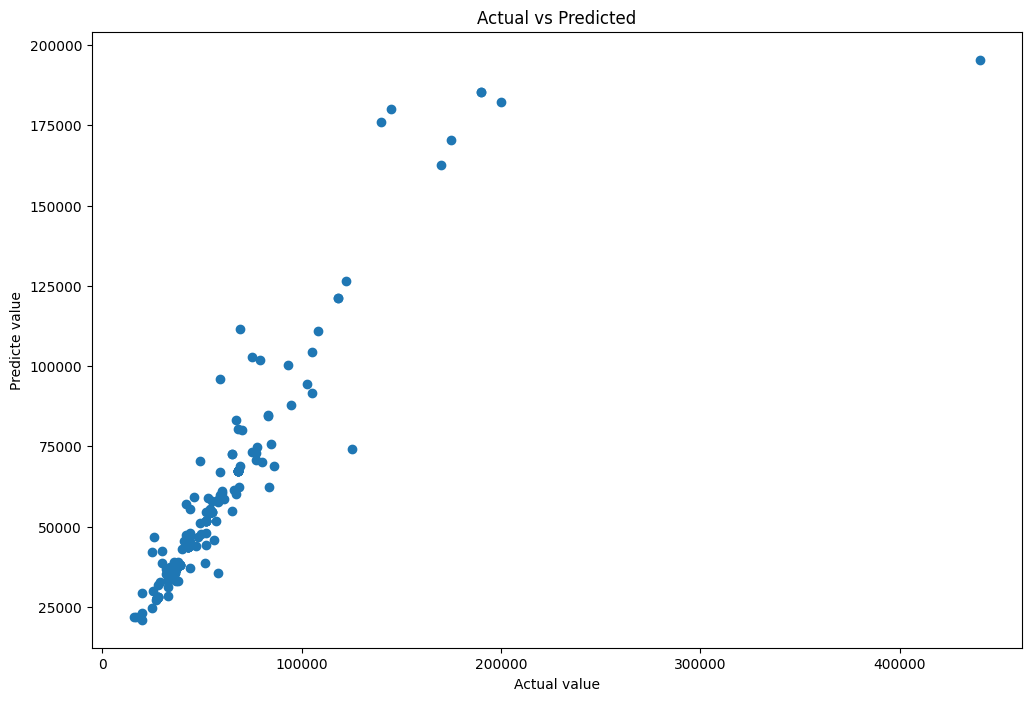

In [135]:
plt.figure(figsize=(12,8))

plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual value")
plt.ylabel("Predicte value")
plt.title("Actual vs Predicted");

In [137]:
residuals = y_test - y_test_pred
residuals

323    -225.636591
861   -3488.373373
30      340.122732
837    -371.605807
294   -2809.631367
          ...     
54    -9278.656970
827   -1000.771385
490     244.138438
753    9990.144331
843   -1069.215280
Name: Discount price, Length: 185, dtype: float64

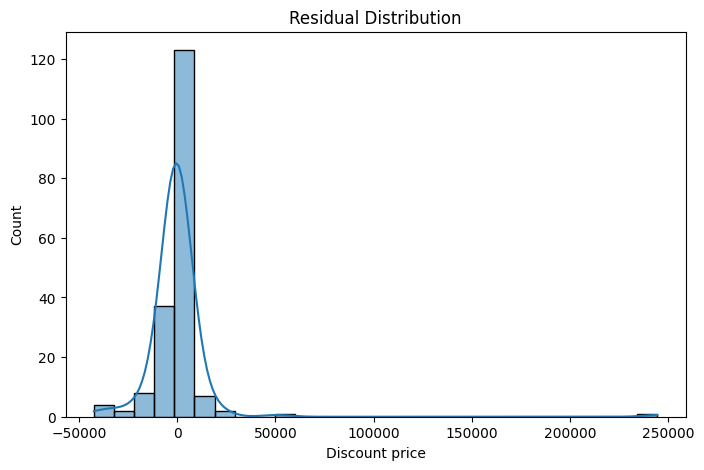

In [138]:
plt.figure(figsize=(8,5))

sns.histplot(residuals,kde=True)
plt.title("Residual Distribution")
plt.show()

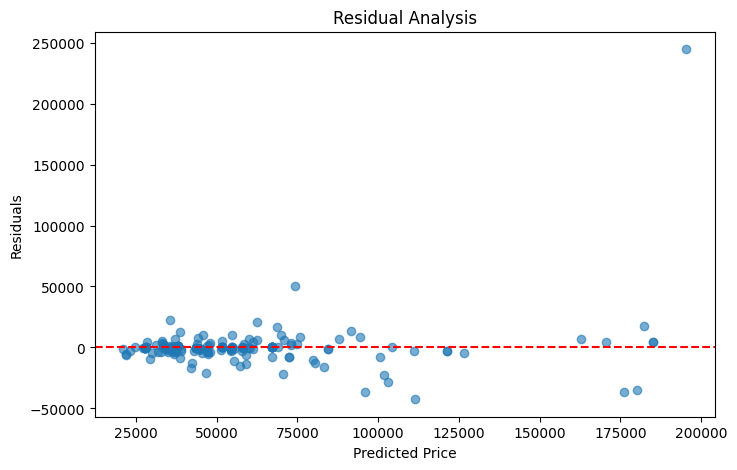

In [140]:
plt.figure(figsize=(8,5))

plt.scatter(y_test_pred,residuals,alpha=0.6)

plt.axhline(y=0,color="red",linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()